In [1]:
import numpy as np
import matplotlib.pyplot as plt 
plt.rc('font',family='Helvetica')
import os

base_path = "../../acoustic/Article-Adding-Test/source_encoding/data-8source"

In [2]:
project_path = base_path
init_model   = np.load(os.path.join(project_path,"model/init_model.npz"))
true_model   = np.load(os.path.join(project_path,"model/true_model.npz"))
init_v = init_model["vp"]
true_v = true_model["vp"]
inv_v_l2 = np.load(os.path.join(project_path,"inversion-GC/iter_vp.npz"))["data"]
inv_v_gc = np.load(os.path.join(project_path,"inversion-L2/iter_vp.npz"))["data"]

In [6]:
inv_v_l2_noencoding = np.load("../../acoustic/02-misfit-functions-test/01-Marmousi2-Test/data/inversion-L2/iter_vp.npz")["data"]
inv_v_gc_noencoding = np.load("../../acoustic/02-misfit-functions-test/01-Marmousi2-Test/data/inversion-GC/iter_vp.npz")["data"]

In [7]:
def MSE(true_v,inv_v):
    nz,nx = true_v.shape
    return np.sum((true_v-inv_v)**2)/(nz*nx)

def MAPE(true_v,inv_v):
    if len(true_v.shape) != len(inv_v.shape):
        nz,nx = true_v.shape
        true_v = true_v[np.newaxis,:,:]
        res = 100/(nx*nz) * np.sum(np.abs(inv_v-true_v)/true_v,axis=(1,2))
    else:
        nz,nx = true_v.shape[-2:]
        res = 100/(nx*nz) * np.sum(np.abs(inv_v-true_v)/true_v)
    return res

from skimage.metrics import structural_similarity as ssim
def SSIM(true_v,inv_v,win_size=11):
    if len(true_v.shape) != len(inv_v.shape):
        ssim_res = []
        for i in range(inv_v.shape[0]):
            vmax = np.max([true_v.max(),inv_v[i].max()])
            vmin = np.min([true_v.min(),inv_v[i].min()])
            temp_ssim =  ssim(true_v,inv_v[i],data_range=vmax-vmin,win_size=win_size)
            ssim_res.append(temp_ssim)
        return ssim_res
    else:
        vmax = np.max([true_v.max(),inv_v.max()])
        vmin = np.min([true_v.min(),inv_v.min()])
        return ssim(true_v,inv_v,data_range=vmax-vmin,win_size=win_size)
    
def SNR(true_v,inv_v):
    if len(true_v.shape) != len(inv_v.shape):
        snr_res = []
        for i in range(inv_v.shape[0]):
            true_norm  = np.sum(true_v**2)
            diff_norm = np.sum((true_v-inv_v[i])**2)
            temp_snr = 10*np.log10(true_norm/diff_norm)
            snr_res.append(temp_snr)
        return snr_res
    else:
        true_norm  = np.sum(true_v**2)
        diff_norm = np.sum((true_v-inv_v)**2)
        temp_snr = 10*np.log10(true_norm/diff_norm)
        return temp_snr

In [28]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 88, 200          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 3000, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition
x = np.arange(nx)*dx/1000
z = np.arange(nz)*dz/1000
x_mesh,z_mesh = np.meshgrid(x,z)
src_z = np.array([1  for i in range(1,nx-1,5)])*dz/1000
src_x = np.array([i  for i in range(1,nx-1,5)])*dx/1000
rcv_z = np.array([1  for i in range(0,nx-1,1)])*dz/1000
rcv_x = np.array([j  for j in range(0,nx-1,1)])*dz/1000
vmin = true_v.min();vmax = true_v.max()

def plot_vel_single_for_all(fig,ax,v,title="",MSE=""):
    plt.rc('font',family='Helvetica')
    # cmap = "jet_r"
    cmap = "rainbow"
    # plm = ax.pcolormesh(x_mesh, z_mesh, v,cmap=cmap,vmin=vmin,vmax=vmax)
    x = np.arange(nx*5)*dx/5/1000
    z = np.arange(nz*5)*dz/5/1000
    x_mesh_new,z_mesh_new = np.meshgrid(x,z)
    from scipy.interpolate import griddata
    v_new = griddata((x_mesh.flatten(), z_mesh.flatten()), v.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
    
    plm = ax.pcolormesh(x_mesh_new, z_mesh_new, v_new,cmap=cmap,vmin=vmin,vmax=vmax,shading="nearest")
    ax.invert_yaxis()
    ax.tick_params(labelsize = 16)
    if title != "":
        ax.set_title(title,fontsize=16)
    if MSE != "":
        ax.text(5.8,0.35,MSE,fontsize=16,c="w")
    return plm

import matplotlib.transforms as mtransforms
def add_right_cax(ax, pad, width):

    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

## Waveform comparation

In [18]:
# obs waveform 
def normalize(data,norm=True):
    if norm:
        # return data/(np.max(np.abs(data),axis=1,keepdims=True))
        return data/(np.max(np.abs(data)))
    else:
        return data
obs_data = np.load(os.path.join(base_path,"waveform/obs_data.npz"),allow_pickle=True)["data"].item()
obs_p = obs_data["p"]
obs_p = normalize(obs_p)
shot = 0
obs_p.shape

(8, 3000, 200)

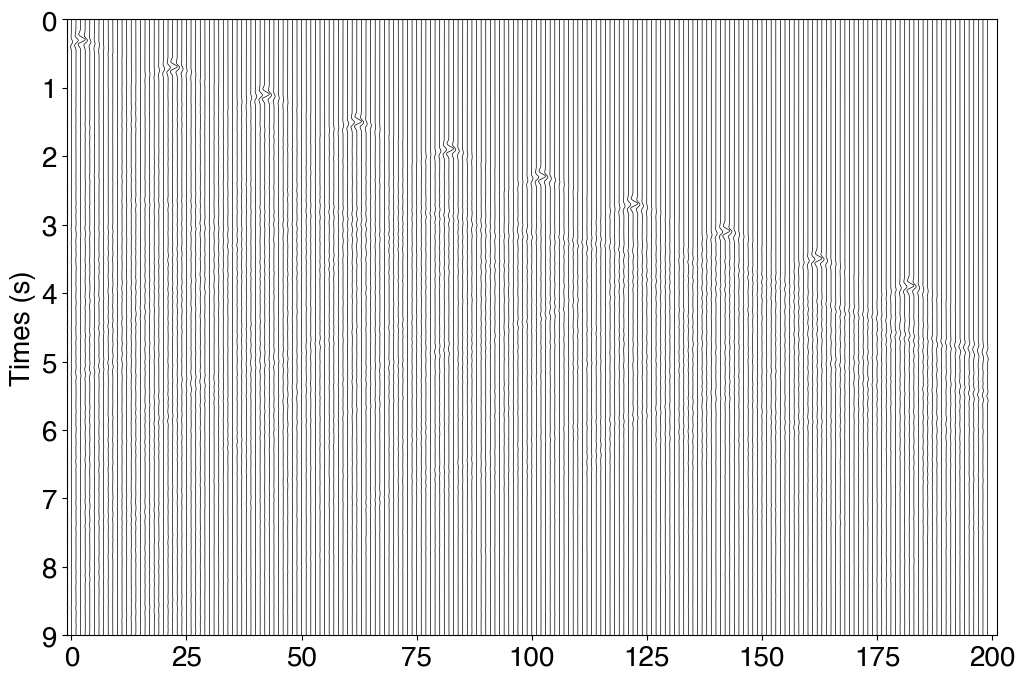

In [19]:
fig,axs = plt.subplots(1,1,figsize=(12,8))
for i in range(0,obs_p.shape[-1]):
    axs.plot(obs_p[shot,:,i]+i,np.arange(obs_p.shape[1])*dt,c='k',linewidth=0.5)

axs.set_xlim(-1,obs_p.shape[-1]+1)
axs.set_ylim(0, obs_p.shape[1]*dt)
axs.invert_yaxis()
axs.set_ylabel("Times (s)",fontsize=20)
axs.tick_params(labelsize = 20)
plt.show()

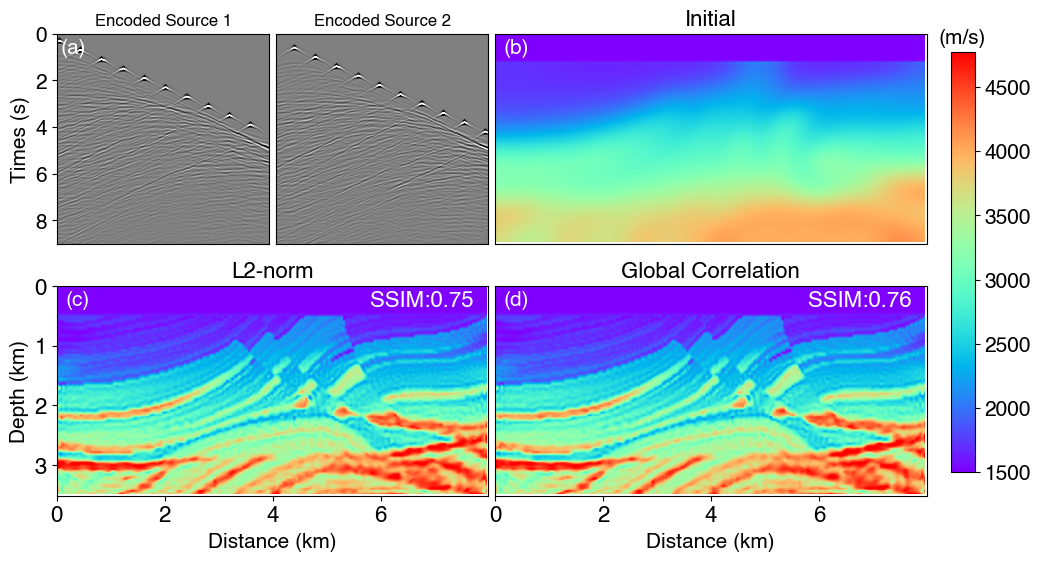

In [29]:
from matplotlib import gridspec
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 4)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax02 = fig.add_subplot(gs[0, 2:])
ax11 = fig.add_subplot(gs[1, :2])
ax12 = fig.add_subplot(gs[1, 2:])

shot1 = 0
shot2 = 3
z_mesh_waveform,x_mesh_waveform = np.meshgrid(np.arange(obs_p.shape[2]),np.arange(obs_p.shape[1])*dt)
ax00.pcolormesh(z_mesh_waveform,x_mesh_waveform,obs_p[shot1],cmap="gray",vmin=-0.2,vmax=0.2)
ax01.pcolormesh(z_mesh_waveform,x_mesh_waveform,obs_p[shot2],cmap="gray",vmin=-0.2,vmax=0.2)
ax00.set_xticks([])
ax01.set_xticks([])
ax01.set_yticks([])
ax00.invert_yaxis()
ax01.invert_yaxis()
ax00.set_title("Encoded Source 1")
ax01.set_title("Encoded Source 2")
ax00.set_ylabel("Times (s)", fontsize=15)
ax00.tick_params(labelsize=15)

im = plot_vel_single_for_all(fig,ax02,true_v[::-1,::]    ,title=r"True")
ax02.invert_yaxis()
plot_vel_single_for_all(fig,ax02,init_v         ,title=r"Initial")
ax02.set_xticks([])
ax02.set_yticks([])

plot_vel_single_for_all(fig,ax11,inv_v_l2[-1]   ,title=r"L2-norm"     ,  MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_l2[-1][12:,:])))
ax11.set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,ax12,inv_v_gc[-1]   ,title=r"Global Correlation",  MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_gc[-1][12:,:])))

# ax11.set_xticks([])
# ax12.set_xticks([])
ax12.set_yticks([])
ax11.set_xlabel("Distance (km)", fontsize=15)
ax12.set_xlabel("Distance (km)", fontsize=15)
ax12.set_yticks([])

# Adjust the position of the subplots to make room for the colorbar
plt.subplots_adjust(hspace=0.2, wspace=0.03, right=0.85)

# Add the colorbar
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title("(m/s)", fontsize=15, loc='center')
cbar.ax.tick_params(labelsize=15)

# Adding labels (a) to (f) in the left upper corner of each subplot
ax00.text(0.02, 0.98, "(a)", transform=ax00.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax02.text(0.02, 0.98, "(b)", transform=ax02.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax11.text(0.02, 0.98, "(c)", transform=ax11.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax12.text(0.02, 0.98, "(d)", transform=ax12.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')

plt.savefig(os.path.join(base_path,"source_encoding.png"),bbox_inches='tight',dpi=100)
plt.show()


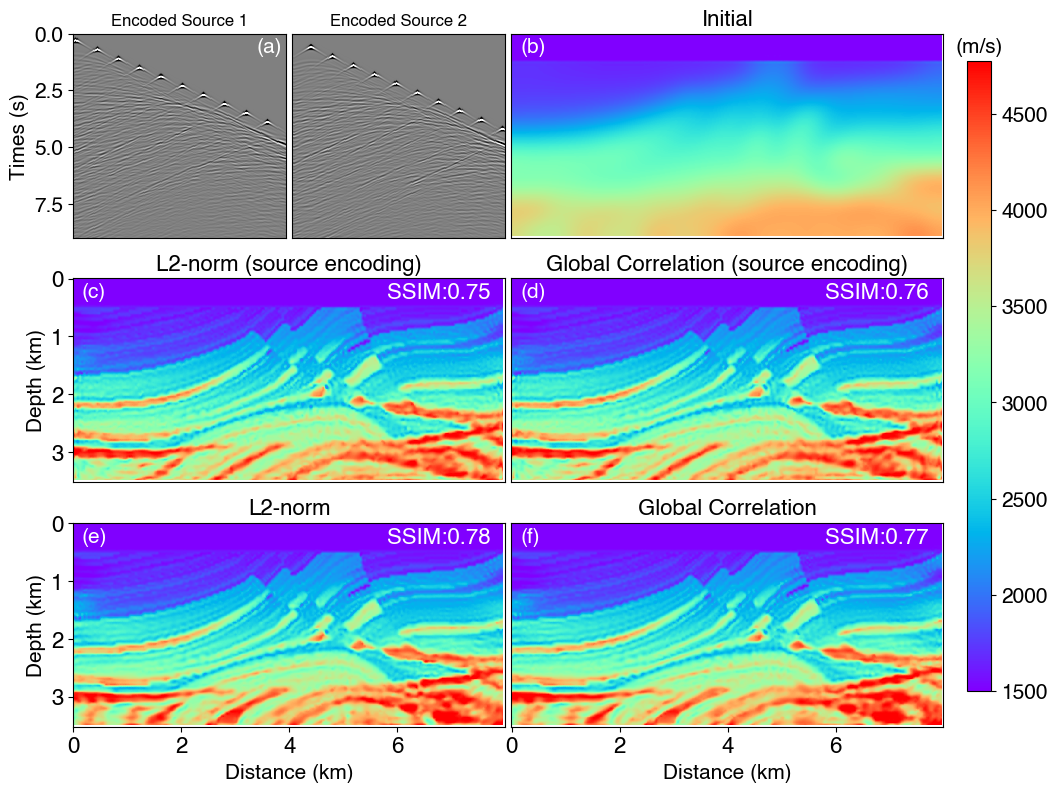

In [31]:
from matplotlib import gridspec
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(3, 4)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax02 = fig.add_subplot(gs[0, 2:])
ax11 = fig.add_subplot(gs[1, :2])
ax12 = fig.add_subplot(gs[1, 2:])
ax21 = fig.add_subplot(gs[2, :2])
ax22 = fig.add_subplot(gs[2, 2:])

shot1 = 0
shot2 = 3
z_mesh_waveform,x_mesh_waveform = np.meshgrid(np.arange(obs_p.shape[2]),np.arange(obs_p.shape[1])*dt)
ax00.pcolormesh(z_mesh_waveform,x_mesh_waveform,obs_p[shot1],cmap="gray",vmin=-0.2,vmax=0.2)
ax01.pcolormesh(z_mesh_waveform,x_mesh_waveform,obs_p[shot2],cmap="gray",vmin=-0.2,vmax=0.2)
ax00.set_xticks([])
ax01.set_xticks([])
ax01.set_yticks([])
ax00.invert_yaxis()
ax01.invert_yaxis()
ax00.set_title("Encoded Source 1")
ax01.set_title("Encoded Source 2")
ax00.set_ylabel("Times (s)", fontsize=15)
ax00.tick_params(labelsize=15)

im = plot_vel_single_for_all(fig,ax02,true_v[::-1,::]    ,title=r"True")
ax02.invert_yaxis()
plot_vel_single_for_all(fig,ax02,init_v                  ,title=r"Initial")

plot_vel_single_for_all(fig,ax11,inv_v_l2[-1]               ,title=r"L2-norm (source encoding)"             ,MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_l2[-1][12:,:])))
ax11.set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,ax12,inv_v_gc[-1]               ,title=r"Global Correlation (source encoding)"  ,MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_gc[-1][12:,:])))

plot_vel_single_for_all(fig,ax21,inv_v_l2_noencoding[-1]   ,title=r"L2-norm"                        ,MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_l2_noencoding[-1][12:,:])))
ax21.set_ylabel("Depth (km)",fontsize=15)
plot_vel_single_for_all(fig,ax22,inv_v_gc_noencoding[-1]   ,title=r"Global Correlation"             ,MSE="SSIM:{:.2f}".format(SSIM(true_v[12:,:],inv_v_gc_noencoding[-1][12:,:])))

ax02.set_xticks([])
ax11.set_xticks([])
ax12.set_xticks([])
ax02.set_yticks([])
ax12.set_yticks([])
ax22.set_yticks([])


# Adjust the position of the subplots to make room for the colorbar
plt.subplots_adjust(hspace=0.2, wspace=0.03, right=0.85)

# Add the colorbar
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title("(m/s)", fontsize=15, loc='center')
cbar.ax.tick_params(labelsize=15)


ax21.set_xlabel("Distance (km)", fontsize=15)
ax22.set_xlabel("Distance (km)", fontsize=15)

# Adding labels (a) to (f) in the left upper corner of each subplot
ax00.text(0.98, 0.98, "(a)", transform=ax00.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='right',c='w')
ax02.text(0.02, 0.98, "(b)", transform=ax02.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax11.text(0.02, 0.98, "(c)", transform=ax11.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax12.text(0.02, 0.98, "(d)", transform=ax12.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax21.text(0.02, 0.98, "(e)", transform=ax21.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')
ax22.text(0.02, 0.98, "(f)", transform=ax22.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='left',c='w')

plt.savefig(os.path.join(base_path,"source_encoding.png"),bbox_inches='tight',dpi=100)
plt.show()
